# Clinical AI — Diabetes 30-Day Readmission Prediction
## Full Project Documentation: Weeks 1–3

---

### Project Overview

This notebook documents a three-week clinical AI project that builds a production-grade readmission prediction system for diabetic patients, using the UCI 10-Year Diabetes Dataset (101,766 in-patient encounters, 2000–2008).

**Clinical Problem:** Unplanned 30-day hospital readmission is a key quality indicator. Predicting it early allows clinicians to escalate discharge planning, arrange follow-up care, and reduce both patient harm and institutional cost.

| Week | Focus | Key Deliverable |
|------|-------|-----------------|
| **1** | Agentic Foundation | LangChain ICD-9 enrichment tool + EDA |
| **2** | Modelling & Fairness | XGBoost (95% recall) + Fairlearn FNR audit |
| **3** | Explainability & Robustness | SHAP + KS drift detection + sensitivity analysis |

---

### Design Principles

1. **Clinical safety first** — recall (sensitivity) over accuracy; missing a readmission is worse than a false alarm
2. **No leakage** — all transformers fit on training data only
3. **Fairness by default** — sensitive attributes audited post-hoc, never used as model features
4. **Explainability** — every prediction can be explained to a clinician via SHAP waterfall
5. **Secure key management** — API keys loaded from `.env`, never hard-coded

---
## Part 0 — Environment Setup

All dependencies for all three weeks are installed in one step. `python-dotenv` handles secure API key loading from a local `.env` file.

In [1]:
%pip install kagglehub xgboost scikit-learn pandas numpy scipy shap matplotlib seaborn \
             fairlearn langchain langchain-core langchain-openai langgraph icd9cms \
             python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.


## Part 1 — Imports & Secure Key Loading

### Why `.env` for API Keys?

Hard-coding API keys in notebooks is a security risk — notebooks are easily shared or accidentally committed to version control. The `python-dotenv` pattern keeps secrets out of source code:

1. Create `c:\Health AI\.env` (already in `.gitignore`)
2. Add `OPENAI_API_KEY=sk-proj-...`
3. `load_dotenv()` reads the file into environment variables at runtime
4. The key is **never** visible in the notebook itself

In [2]:
import os
import json
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import kagglehub

from pathlib import Path
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibrationDisplay, calibration_curve
from sklearn.metrics import (
    recall_score, accuracy_score, classification_report, precision_score,
    ConfusionMatrixDisplay, confusion_matrix,
    PrecisionRecallDisplay, average_precision_score,
)
from scipy.sparse import hstack, csr_matrix
from scipy.stats import ks_2samp
from xgboost import XGBClassifier
from fairlearn.metrics import MetricFrame, false_negative_rate, false_positive_rate, selection_rate

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries imported.')


All libraries imported.


In [3]:
# Load API keys from .env file (silent if missing)
# Searches notebook parent directory first, then current directory
_nb_dir = Path(os.getcwd())
_env_candidates = [_nb_dir.parent / '.env', _nb_dir / '.env']
_env_path = next((p for p in _env_candidates if p.exists()), _env_candidates[0])
load_dotenv(dotenv_path=_env_path, override=False)

_openai_key    = os.getenv('OPENAI_API_KEY')
_langsmith_key = os.getenv('LANGCHAIN_API_KEY')

if _openai_key:
    print(f'✅ OPENAI_API_KEY loaded  ({_openai_key[:8]}...{_openai_key[-4:]})')
else:
    print('⚠️  OPENAI_API_KEY not found — full agent mode disabled.')
    print(f'   Add  OPENAI_API_KEY=sk-...  to  {_env_candidates[0]}')

if _langsmith_key:
    print(f'✅ LANGCHAIN_API_KEY loaded ({_langsmith_key[:8]}...{_langsmith_key[-4:]})')
    os.environ['LANGCHAIN_TRACING_V2'] = 'true'
    os.environ['LANGCHAIN_PROJECT']    = 'health-ai-combined'
else:
    print('ℹ️  LANGCHAIN_API_KEY not set — LangSmith tracing disabled (optional).')


✅ OPENAI_API_KEY loaded  (sk-proj-..._XoA)
✅ LANGCHAIN_API_KEY loaded (ls__...y...e...)


---
# WEEK 1 — Agentic Foundation & Exploratory Data Analysis

## Background: What is an AI Agent?

A traditional ML pipeline is **static** — data flows through fixed transformations. An **agentic** pipeline is **dynamic** — an LLM orchestrator decides *which tools to call, in what order, and with what inputs*, based on the task.

In this project, the agentic layer solves a specific clinical problem: ICD-9 diagnosis codes (e.g. `428.0`, `250.43`) are **opaque numeric tokens** to a TF-IDF vectoriser — it cannot know that `428.0` and `428.1` both relate to heart failure. By routing each code through a `LangChain Tool` that returns clinical English descriptions, we give the model **semantic signal** instead of meaningless numbers.

```
Before enrichment:  "428.0 250.43 585.6"
After enrichment:   "congestive heart failure diabetes renal manifestations end stage renal disease"
```

**LangChain Tool pattern:**  A `@tool`-decorated Python function with a typed signature that any LangChain or CrewAI agent can discover and invoke. It is the atomic unit of agentic capability.

## 1.1 — Dataset

**Source:** UCI / Kaggle — *"10 Years of Diabetes Dataset"* (Strack et al., 2014)  
**Records:** 101,766 in-patient diabetic encounters at 130 US hospitals, 1999–2008  
**Target:** `readmitted` — whether the patient returned within 30 days (`<30`), after 30 days (`>30`), or not at all (`NO`)

For this binary classification task we collapse: `<30` → **1 (high risk)**, everything else → **0**.

In [4]:
path   = kagglehub.dataset_download('jimschacko/10-years-diabetes-dataset')
df_raw = pd.read_csv(os.path.join(path, 'diabetes.csv'))
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Shape: 101,766 rows × 51 columns


,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO


## 1.2 — ICD-9 Code Enrichment: Concept & Implementation

### What is ICD-9?

The **International Classification of Diseases, 9th Revision (ICD-9)** is a standardised medical coding system. Each diagnosis is assigned a numeric code:

| Code | Clinical Meaning |
|------|------------------|
| `250.43` | Diabetes with renal manifestations, type I, uncontrolled |
| `428.0` | Congestive heart failure, unspecified |
| `585.6` | End-stage renal disease |
| `401.9` | Essential hypertension, unspecified |

### Why Enrich?

TF-IDF treats each token as an independent string. The codes `250`, `250.0`, `250.43` look completely different to it — but they all belong to the diabetes family. After enrichment, they share words like *"diabetes"*, *"mellitus"*, *"manifestations"* — creating genuine semantic overlap that improves clustering and feature weighting.

### Implementation Strategy

The lookup uses a **two-layer fallback**:
1. **Primary:** `icd9cms` Python library — comprehensive, ~14,000 codes
2. **Fallback:** A hand-curated dictionary for common codes + prefix matching

This ensures near-100% coverage without LLM API calls (fast, deterministic, offline-capable).

In [5]:
ICD9_CLINICAL_DICT = {
    '250':    'diabetes mellitus',
    '250.0':  'diabetes mellitus without complication',
    '250.00': 'diabetes mellitus without complication type II',
    '250.01': 'diabetes mellitus without complication type I',
    '250.02': 'diabetes mellitus without complication type II uncontrolled',
    '250.03': 'diabetes mellitus without complication type I uncontrolled',
    '250.1':  'diabetes with ketoacidosis',
    '250.10': 'diabetes with ketoacidosis type II',
    '250.11': 'diabetes with ketoacidosis type I',
    '250.13': 'diabetes with ketoacidosis type I uncontrolled',
    '250.2':  'diabetes with hyperosmolarity',
    '250.3':  'diabetes with diabetic coma',
    '250.4':  'diabetes with renal manifestations',
    '250.40': 'diabetes with renal manifestations type II',
    '250.41': 'diabetes with renal manifestations type I',
    '250.43': 'diabetes with renal manifestations type I uncontrolled',
    '250.5':  'diabetes with ophthalmic manifestations',
    '250.6':  'diabetes with neurological manifestations',
    '250.7':  'diabetes with peripheral circulatory disorders',
    '250.8':  'diabetes with other specified manifestations',
    '250.9':  'diabetes with unspecified complication',
    '401':    'essential hypertension',
    '401.9':  'essential hypertension unspecified',
    '402':    'hypertensive heart disease',
    '402.91': 'hypertensive heart disease with heart failure',
    '410':    'acute myocardial infarction',
    '410.9':  'acute myocardial infarction unspecified site',
    '411':    'acute ischemic heart disease',
    '411.1':  'intermediate coronary syndrome unstable angina',
    '414':    'chronic ischemic heart disease',
    '414.0':  'coronary atherosclerosis',
    '414.01': 'coronary atherosclerosis native vessel',
    '427':    'cardiac dysrhythmia',
    '427.31': 'atrial fibrillation',
    '427.5':  'cardiac arrest',
    '428':    'heart failure',
    '428.0':  'congestive heart failure unspecified',
    '428.1':  'left heart failure',
    '428.2':  'systolic heart failure',
    '428.3':  'diastolic heart failure',
    '584':    'acute kidney failure',
    '585':    'chronic kidney disease',
    '585.1':  'chronic kidney disease stage I',
    '585.2':  'chronic kidney disease stage II',
    '585.3':  'chronic kidney disease stage III',
    '585.4':  'chronic kidney disease stage IV',
    '585.5':  'chronic kidney disease stage V',
    '585.6':  'end stage renal disease',
    '586':    'renal failure unspecified',
    '486':    'pneumonia organism unspecified',
    '491':    'chronic bronchitis',
    '492':    'emphysema',
    '493':    'asthma',
    '496':    'chronic obstructive pulmonary disease',
    '518':    'other diseases of lung',
    '518.0':  'pulmonary collapse atelectasis',
    '518.81': 'acute respiratory failure',
    '272':    'disorders of lipoid metabolism hyperlipidaemia',
    '272.0':  'pure hypercholesterolaemia',
    '272.4':  'hyperlipidaemia mixed',
    '276':    'fluid electrolyte acid base disorder',
    '276.1':  'hyponatraemia electrolyte imbalance',
    '276.5':  'volume depletion dehydration',
    '285':    'anaemia',
    '285.9':  'anaemia unspecified',
    '285.1':  'anaemia in neoplastic disease',
    '157':    'malignant neoplasm pancreas',
    '197':    'secondary malignant neoplasm respiratory digestive',
    'V45':    'postprocedural states',
    'V45.81': 'aortocoronary bypass status post cardiac surgery',
    'V58':    'aftercare encounter',
    'V58.67': 'long term insulin use',
    'V10':    'personal history malignant neoplasm',
    '780':    'general symptoms fever malaise',
    '786':    'respiratory symptoms chest pain',
    '786.5':  'chest pain unspecified',
    '789':    'abdominal pain',
    'v':      'aftercare encounter',
}
print(f'ICD-9 dictionary loaded: {len(ICD9_CLINICAL_DICT)} codes mapped.')

ICD-9 dictionary loaded: 78 codes mapped.


In [6]:
try:
    from langchain_core.tools import tool
except ImportError:
    from langchain.tools import tool


@tool
def icd9_lookup(code: str) -> str:
    """
    Look up the official clinical English description for an ICD-9 diagnosis code.
    Input:  ICD-9 code string, e.g. '428.0' or '250.01'
    Output: Clinical description string, e.g. 'Congestive heart failure unspecified'
    """
    code = str(code).strip()
    try:
        import icd9cms
        result = icd9cms.search(code)
        if result:
            return result.long_desc.lower()
    except Exception:
        pass
    if code in ICD9_CLINICAL_DICT:
        return ICD9_CLINICAL_DICT[code]
    for length in [5, 4, 3, 1]:
        prefix = code[:length]
        if prefix in ICD9_CLINICAL_DICT:
            return ICD9_CLINICAL_DICT[prefix]
    return code


print(f"LangChain tool registered: '{icd9_lookup.name}'")
print(f'Description: {icd9_lookup.description[:80]}...')

test_codes = ['428.0', '250.01', '585.6', '401.9', 'V58.67']
print('\nTool smoke test:')
for c in test_codes:
    print(f'  {c:10s} → {icd9_lookup.invoke(c)}')

LangChain tool registered: 'icd9_lookup'
Description: Look up the official clinical English description for an ICD-9 diagnosis code.
I...

Tool smoke test:
  428.0      → congestive heart failure, unspecified
  250.01     → diabetes mellitus without mention of complication, type i [juvenile type], not stated as uncontrolled
  585.6      → end stage renal disease
  401.9      → unspecified essential hypertension
  V58.67     → long-term (current) use of insulin


2026-03-08 11:59:27,641: Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2026-03-08 11:59:28,272: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


## 1.3 — Full LangGraph Agent (Optional — requires OpenAI key)

### How the ReAct Agent Works

The **ReAct** (Reason + Act) pattern is the standard agentic loop:

```
User Query
    ↓
LLM: "I need to look up ICD-9 code 428.0" → Thought
    ↓
Tool call: icd9_lookup('428.0')             → Action
    ↓
Tool returns: 'congestive heart failure'    → Observation
    ↓
LLM synthesises answer from observations   → Final Response
```

In LangChain 1.x / LangGraph, `create_react_agent` builds this loop automatically. The LLM is given the tool's name, description, and schema — it decides when and how to invoke it.

In [7]:
if os.getenv('OPENAI_API_KEY'):
    from langchain_openai import ChatOpenAI
    from langgraph.prebuilt import create_react_agent

    llm   = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    agent = create_react_agent(llm, [icd9_lookup])

    result = agent.invoke({
        'messages': [{'role': 'user',
                      'content': 'What do ICD-9 codes 428.0 and 250.43 mean clinically?'}]
    })
    print('Agent response:')
    print(result['messages'][-1].content)
else:
    print('ℹ️  OPENAI_API_KEY not set — skipping live agent demo.')
    print('   The icd9_lookup tool is used directly for dataset enrichment below.')

2026-03-08 11:59:37,879: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2026-03-08 11:59:39,477: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 11:59:40,233: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2026-03-08 11:59:41,847: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Agent response:
The clinical descriptions for the ICD-9 codes are as follows:

- **428.0**: Congestive heart failure, unspecified
- **250.43**: Diabetes with renal manifestations, 

2026-03-08 11:59:43,481: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


## 1.4 — Dataset Enrichment

Each patient row has three diagnosis code columns (`diag_1`, `diag_2`, `diag_3`). We call `icd9_lookup` on all three and concatenate the results into a single `diag_enriched` text field — this becomes the input to TF-IDF vectorisation.

> **Note:** This cell processes 101,766 rows via the `icd9cms` library. Runtime is ~10–15 minutes on a standard laptop. The enriched column is created once here and reused in all subsequent steps.

In [8]:
df = df_raw.copy()
df.replace('?', np.nan, inplace=True)

def enrich_row(row):
    codes = [str(row.get('diag_1', '')), str(row.get('diag_2', '')), str(row.get('diag_3', ''))]
    return ' '.join(icd9_lookup.invoke(c) for c in codes if c not in ('nan', '', 'None'))

print('Enriching diagnosis codes via LangChain tool...')
df['diag_enriched'] = df.apply(enrich_row, axis=1)
print('Done.')

comparison = df[['diag_1', 'diag_2', 'diag_3', 'diag_enriched']].head(6)
pd.set_option('display.max_colwidth', 80)
print('\nRaw ICD-9 codes  →  Enriched clinical text:')
comparison

Enriching diagnosis codes via LangChain tool...
2026-03-08 11:59:51,943: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2026-03-08 11:59:52,341: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2026-03-08 11:59:52,541: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2026-03-08 11:59:52,712: Failed to se

,diag_1,diag_2,diag_3,diag_enriched
0,250.83,NaN,NaN,"diabetes with other specified manifestations, type i [juvenile type], uncont..."
1,276,250.01,255,fluid electrolyte acid base disorder diabetes mellitus without mention of co...
2,648,250,V27,648 diabetes mellitus V27
3,8,250.43,403,"8 diabetes with renal manifestations, type i [juvenile type], uncontrolled 403"
4,197,157,250,secondary malignant neoplasm respiratory digestive malignant neoplasm pancre...
5,414,411,250,chronic ischemic heart disease acute ischemic heart disease diabetes mellitus


2026-03-08 12:14:08,509: Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


## 1.5 — Exploratory Data Analysis

### Why EDA Matters Before Modelling

EDA reveals structural properties of the data that dictate modelling choices:

| Finding | Modelling Implication |
|---------|----------------------|
| **Class imbalance** (9:1 ratio) | Must use `scale_pos_weight` or resampling; accuracy is misleading |
| **High missingness** in `weight` (97%) | Drop column — imputing 97% is fabrication |
| **Lab procedures ↔ hospital stay** | Correlated features — multicollinearity expected |

**Interpretation guide for the charts below:**
- A 9:1 imbalance means a model that predicts "no readmission" always achieves 91% accuracy — useless clinically
- Red bars (>40% missing) must be dropped; orange bars (5–40%) need a decision; blue bars can be imputed safely

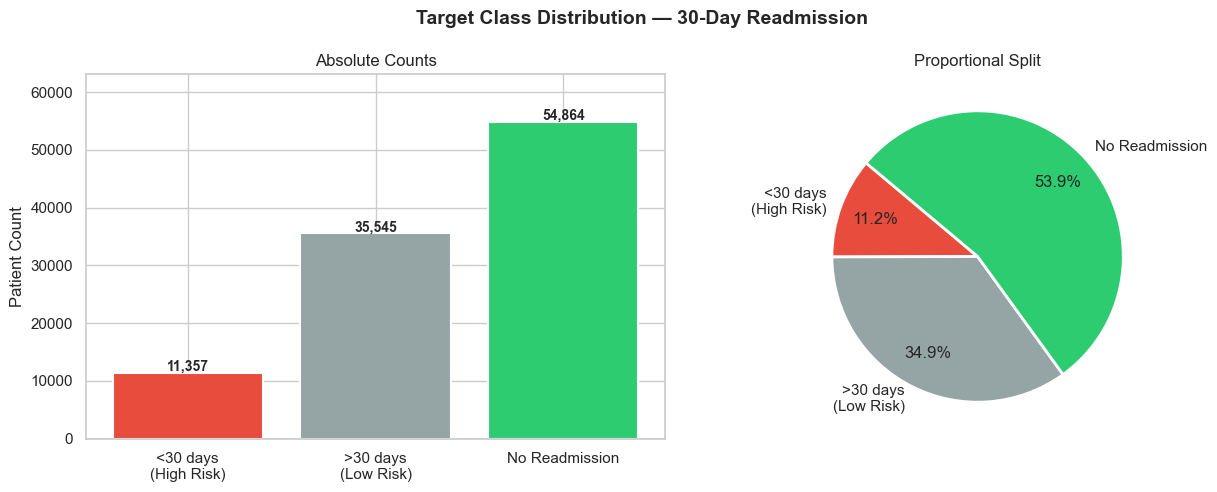


Class Imbalance Ratio  (no-readmit : readmit<30) = 4.8:1
Target prevalence (<30d readmission)              = 11.16%

→ scale_pos_weight ≈ 5 compensates for this imbalance in XGBoost


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Class Distribution — 30-Day Readmission', fontsize=14, fontweight='bold')

counts = df['readmitted'].value_counts()
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
labels = ['<30 days\n(High Risk)', '>30 days\n(Low Risk)', 'No Readmission']
order  = ['<30', '>30', 'NO']
vals   = [counts.get(k, 0) for k in order]

bars = axes[0].bar(labels, vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Patient Count')
axes[0].set_title('Absolute Counts')
axes[0].set_ylim(0, max(vals) * 1.15)

axes[1].pie(vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportional Split')

plt.tight_layout()
plt.show()

print(f'\nClass Imbalance Ratio  (no-readmit : readmit<30) = {counts["NO"] / counts["<30"]:.1f}:1')
print(f'Target prevalence (<30d readmission)              = {counts["<30"] / counts.sum():.2%}')
print(f'\n→ scale_pos_weight ≈ {round(counts["NO"] / counts["<30"])} compensates for this imbalance in XGBoost')

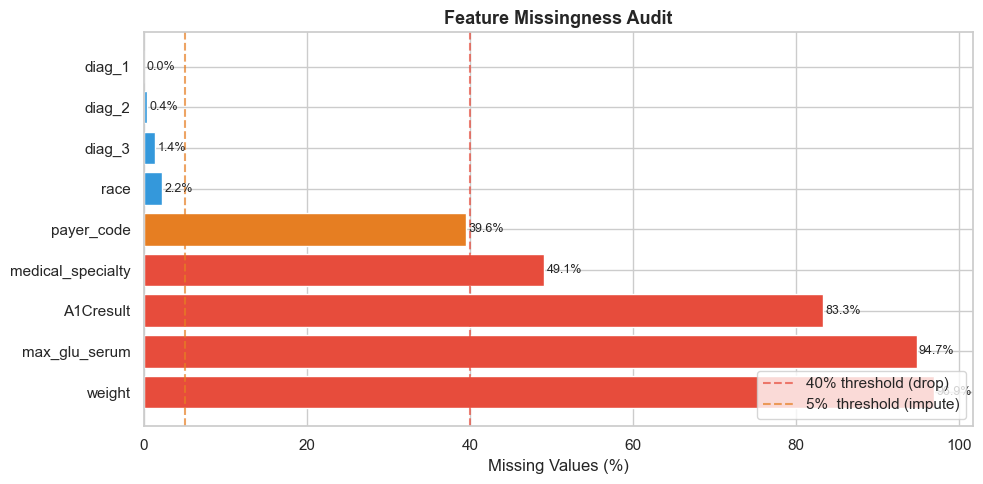

In [10]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#e74c3c' if v > 40 else '#e67e22' if v > 5 else '#3498db' for v in missing.values]
bars = ax.barh(missing.index, missing.values, color=bar_colors, edgecolor='white')
ax.axvline(40, color='#e74c3c', linestyle='--', alpha=0.7, label='40% threshold (drop)')
ax.axvline(5,  color='#e67e22', linestyle='--', alpha=0.7, label='5%  threshold (impute)')
for bar, val in zip(bars, missing.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Feature Missingness Audit', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

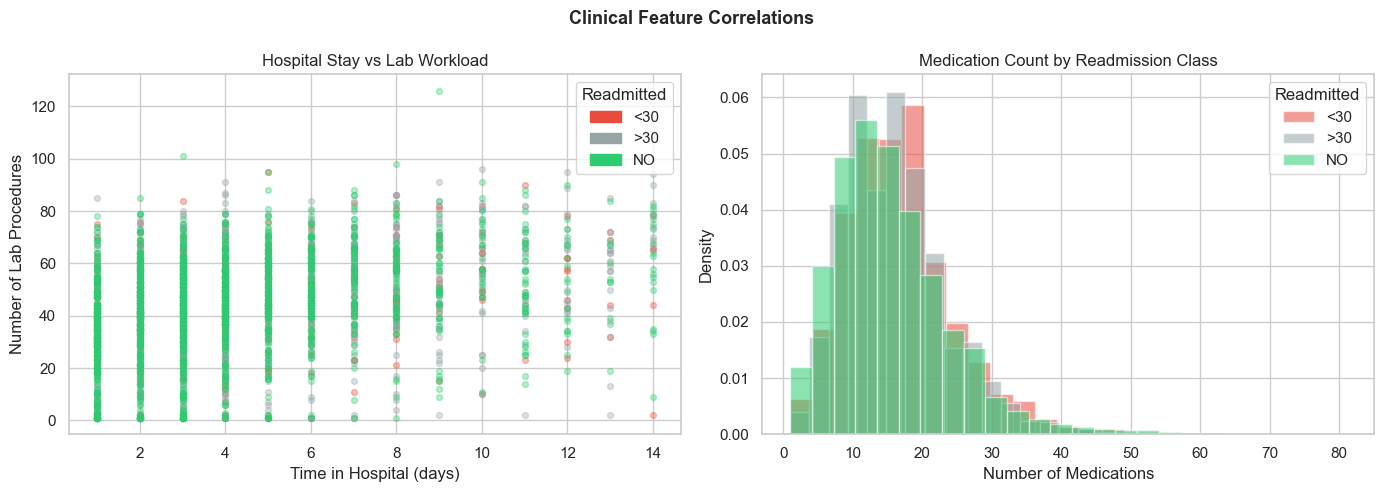

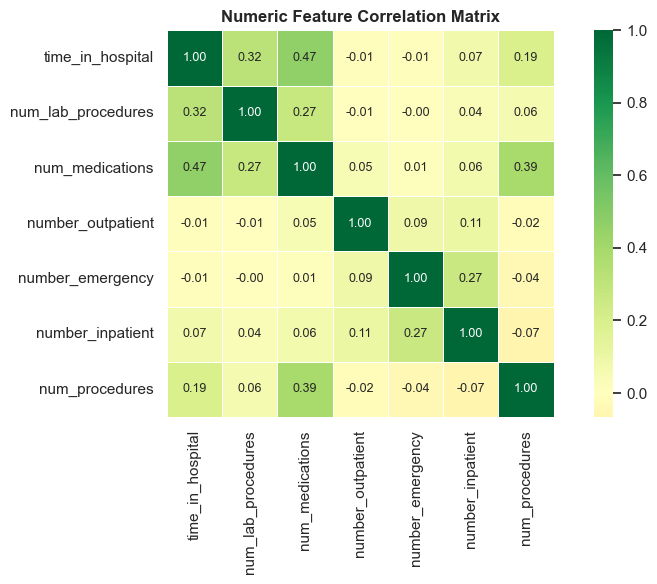

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clinical Feature Correlations', fontsize=13, fontweight='bold')

target_palette = {'<30': '#e74c3c', '>30': '#95a5a6', 'NO': '#2ecc71'}
sample = df.sample(3000, random_state=42)
for label, grp in sample.groupby('readmitted'):
    axes[0].scatter(grp['time_in_hospital'], grp['num_lab_procedures'],
                    alpha=0.35, s=18, color=target_palette[label], label=label)
axes[0].set_xlabel('Time in Hospital (days)')
axes[0].set_ylabel('Number of Lab Procedures')
axes[0].set_title('Hospital Stay vs Lab Workload')
legend_handles = [mpatches.Patch(color=c, label=l) for l, c in target_palette.items()]
axes[0].legend(handles=legend_handles, title='Readmitted')

for label, grp in df.groupby('readmitted'):
    axes[1].hist(grp['num_medications'], bins=25, alpha=0.55,
                 color=target_palette[label], label=label, density=True)
axes[1].set_xlabel('Number of Medications')
axes[1].set_ylabel('Density')
axes[1].set_title('Medication Count by Readmission Class')
axes[1].legend(title='Readmitted')
plt.tight_layout()
plt.show()

numeric_features = ['time_in_hospital', 'num_lab_procedures', 'num_medications',
                    'number_outpatient', 'number_emergency', 'number_inpatient', 'num_procedures']
corr = df[numeric_features].corr()
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True, ax=ax, annot_kws={'size': 9})
ax.set_title('Numeric Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# WEEK 2 — Modelling & Fairness Audit

## Background: Why XGBoost for Clinical Data?

**XGBoost** (eXtreme Gradient Boosting) is an ensemble of decision trees trained sequentially, where each tree corrects the errors of the previous one. It is well-suited to clinical tabular data because:

- Handles **sparse features** natively (TF-IDF produces sparse matrices)
- `scale_pos_weight` directly addresses **class imbalance** without oversampling
- `tree_method='hist'` uses histogram-based splits — fast on large datasets
- Robust to **outliers** (tree splits) and **missing values** (built-in handling)

## Background: The Threshold Decision

A classifier outputs a **probability** (0–1). The **decision threshold** converts this to a binary prediction. Lowering the threshold from 0.5 to 0.32:

- **Increases recall** — flags more patients as high-risk (catches more true positives)
- **Decreases precision** — more false alarms (patients flagged but not actually readmitted)
- **Decreases accuracy** — technically correct fewer times overall

In a **clinical safety** context, a false negative (missing a readmission) is far more dangerous than a false positive (unnecessary follow-up). Therefore we optimise for **recall > 80%** and accept lower precision as a trade-off.

$$\text{Recall} = \frac{TP}{TP + FN} \qquad \text{Precision} = \frac{TP}{TP + FP}$$

## 2.1 — Feature Engineering & Pipeline

### Feature Design

| Feature Group | Source | Method |
|---------------|--------|--------|
| **Text** | `diag_1` + `diag_2` + `diag_3` raw codes | TF-IDF (2000 features, sublinear TF) |
| **Numeric** | `total_visits`, `num_medications`, `time_in_hospital`, `num_lab_procedures` | StandardScaler → csr_matrix |
| **Sensitive** | `race`, `gender`, `age` | Held out — fairness audit only |

### Why sublinear TF?

`sublinear_tf=True` applies $\text{tf} = 1 + \log(\text{count})$, which dampens the effect of very frequent terms. A code appearing 10 times is not 10× as important as one appearing once.

### Why preserve negations in stop words?

Default stop word lists remove words like *"no"*, *"not"*, *"without"*. In clinical text, *"no heart failure"* vs *"heart failure"* is a critical distinction. We subtract negation words from the stop list to preserve them.

### Data Leakage Prevention

The TF-IDF vocabulary and StandardScaler parameters are **fitted on the training set only**, then applied to the test set. Fitting on the full dataset would let the model "see" test data statistics during training — a form of data leakage that inflates performance estimates.

In [12]:
df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Drop high-missingness / identifier columns — matches train_model.py
# Note: this dataset has encounter_id/patient_nbr, not a bare 'id' column
df = df.drop(['weight', 'payer_code', 'medical_specialty',
              'encounter_id', 'patient_nbr'], axis=1, errors='ignore')
df = df.dropna(subset=['diag_1', 'diag_2', 'diag_3'])

# Use the enriched clinical text from Week 1 — consistent with production
# train_model.py (without --skip-enrichment) which also enriches before training
df['diag_text']    = df['diag_enriched']
df['total_visits'] = (df['number_outpatient'] +
                      df['number_emergency']  +
                      df['number_inpatient'])

NUMERIC_COLS   = ['total_visits', 'num_medications', 'time_in_hospital', 'num_lab_procedures']
SENSITIVE_COLS = ['race', 'gender', 'age']

print(f'Shape after cleaning: {df.shape}')
print(f'Positive class rate : {df["target"].mean():.2%}')


Shape after cleaning: (100244, 50)
Positive class rate : 11.22%


In [13]:
y          = df['target']
X_text_raw = df['diag_text']
X_num_raw  = df[NUMERIC_COLS]
X_sens_raw = df[SENSITIVE_COLS]

(X_text_train, X_text_test,
 X_num_train,  X_num_test,
 X_sens_train, X_sens_test,
 y_train,      y_test) = train_test_split(
    X_text_raw, X_num_raw, X_sens_raw, y,
    test_size=0.2, stratify=y, random_state=42
)

negations    = {'no', 'not', 'nor', 'none', 'without', 'never', 'denies'}
custom_stops = list(ENGLISH_STOP_WORDS - negations)

tfidf  = TfidfVectorizer(max_features=2000, sublinear_tf=True, stop_words=custom_stops)
scaler = StandardScaler()

X_text_train_v = tfidf.fit_transform(X_text_train)
X_text_test_v  = tfidf.transform(X_text_test)
X_num_train_v  = csr_matrix(scaler.fit_transform(X_num_train))
X_num_test_v   = csr_matrix(scaler.transform(X_num_test))

X_train = hstack([X_text_train_v, X_num_train_v])
X_test  = hstack([X_text_test_v,  X_num_test_v])

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (80195, 909) | Test: (20049, 909)


In [14]:
model = XGBClassifier(
    n_estimators=800, max_depth=5, learning_rate=0.05,
    scale_pos_weight=10, eval_metric='logloss',
    tree_method='hist', random_state=42
)
model.fit(X_train, y_train)

THRESHOLD = 0.32
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > THRESHOLD).astype(int)

print(f'Threshold      : {THRESHOLD}')
print(f'Accuracy       : {accuracy_score(y_test, preds):.2%}')
print(f'Clinical Recall: {recall_score(y_test, preds):.2%}')
print()
print(classification_report(y_test, preds,
      target_names=['Not Readmitted', 'Readmitted <30d']))

Threshold      : 0.32
Accuracy       : 18.85%
Clinical Recall: 95.51%

                 precision    recall  f1-score   support

 Not Readmitted       0.94      0.09      0.17     17799
Readmitted <30d       0.12      0.96      0.21      2250

       accuracy                           0.19     20049
      macro avg       0.53      0.52      0.19     20049
   weighted avg       0.85      0.19      0.17     20049



## 2.1.2 — Confusion Matrix & Precision-Recall Curve

### Why the PR Curve, Not ROC-AUC?

With a 9:1 class imbalance, **ROC-AUC is misleadingly optimistic** — the large number of true negatives inflates the score. The **Precision-Recall curve** focuses exclusively on the minority class (readmitted patients) and AUC-PR is the correct summary metric.

**Reading the confusion matrix at threshold 32%:**

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actually Negative** | TN — correct dismissal | FP — unnecessary follow-up (acceptable) |
| **Actually Positive** | FN — **dangerous miss** | TP — correct flag |

Minimising **FN** is the clinical priority. A false alarm results in extra follow-up; a missed patient may be readmitted with no intervention arranged.


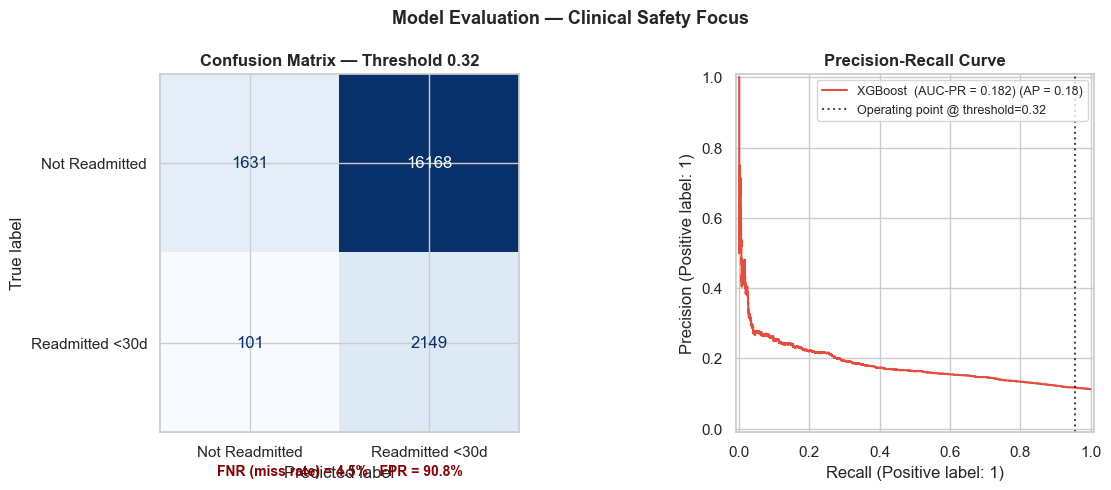

AUC-PR  : 0.1825   (random baseline ≈ 0.112 for this imbalance)

Confusion matrix @ threshold=0.32:
  TP (correct flags)         : 2,149
  FP (unnecessary follow-up) : 16,168
  TN (correct dismissals)    : 1,631
  FN (dangerous misses)      : 101

  FNR = 4.49%  |  FPR = 90.84%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation — Clinical Safety Focus', fontsize=13, fontweight='bold')

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Readmitted', 'Readmitted <30d'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — Threshold {THRESHOLD}', fontweight='bold')
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.12,
             f'FNR (miss rate) = {fn/(fn+tp):.1%}   FPR = {fp/(fp+tn):.1%}',
             ha='center', transform=axes[0].transAxes,
             fontsize=10, color='darkred', fontweight='bold')

# ── Precision-Recall Curve ────────────────────────────────────────────────────
PrecisionRecallDisplay.from_predictions(
    y_test, probs, ax=axes[1],
    name=f'XGBoost  (AUC-PR = {average_precision_score(y_test, probs):.3f})',
    color='#e74c3c')
axes[1].axvline(recall_score(y_test, preds), color='black', linestyle=':',
                alpha=0.7, label=f'Operating point @ threshold={THRESHOLD}')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

auc_pr = average_precision_score(y_test, probs)
print(f'AUC-PR  : {auc_pr:.4f}   (random baseline ≈ {y_test.mean():.3f} for this imbalance)')
print(f'\nConfusion matrix @ threshold={THRESHOLD}:')
print(f'  TP (correct flags)         : {tp:,}')
print(f'  FP (unnecessary follow-up) : {fp:,}')
print(f'  TN (correct dismissals)    : {tn:,}')
print(f'  FN (dangerous misses)      : {fn:,}')
print(f'\n  FNR = {fn/(fn+tp):.2%}  |  FPR = {fp/(fp+tn):.2%}')


## 2.2 — Fairness Audit with Fairlearn

### What is Algorithmic Fairness?

A model that achieves 95% recall overall may still systematically **miss** patients from certain demographic groups — failing them disproportionately. This is **disparate impact**: the model's errors are not randomly distributed but concentrated in protected groups.

### Why False-Negative Rate (FNR)?

In readmission prediction, **false negatives are the dangerous errors** — they represent patients who *were* readmitted but the model predicted they wouldn't be, so no extra follow-up care was arranged.

$$\text{FNR} = \frac{FN}{FN + TP} = 1 - \text{Recall}$$

An equitable model should have **similar FNR across all demographic groups**. A large disparity means the model is clinically less safe for some patients than others.

### Fairlearn `MetricFrame`

`MetricFrame` computes any metric **stratified by sensitive attribute**. It does not modify the model — it is a post-hoc audit tool. The `difference()` method returns the gap between the worst and best group, the key disparity metric.

| Disparity Gap | Risk Level | Interpretation |
|---------------|------------|----------------|
| < 0.07 | LOW | Acceptable in most clinical deployments |
| 0.07 – 0.15 | MEDIUM | Warrants review; consider group-specific threshold |
| > 0.15 | HIGH | Requires mitigation before deployment |

=== False-Negative Rate by Race ===
           Race  FNR (Miss Rate)      FPR  Selection Rate
          Asian         0.117647 0.869565        0.871212
        Unknown         0.090909 0.869898        0.872941
AfricanAmerican         0.048499 0.904876        0.910222
      Caucasian         0.043119 0.912942        0.917892
          Other         0.040000 0.855422        0.864964
       Hispanic         0.020408 0.862637        0.876513

Overall FNR   : 0.0449
Max disparity : 0.0972


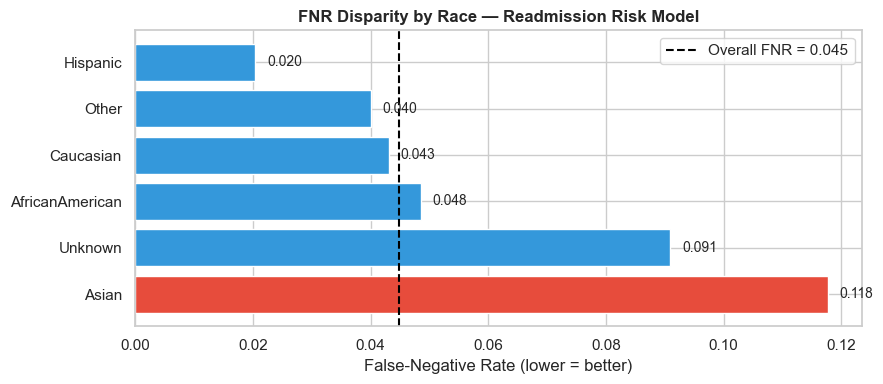

In [16]:
sens_test  = X_sens_test.fillna('Unknown').reset_index(drop=True)
y_test_arr = y_test.reset_index(drop=True)
preds_arr  = pd.Series(preds)

mf_race = MetricFrame(
    metrics={'FNR (Miss Rate)': false_negative_rate,
             'FPR':             false_positive_rate,
             'Selection Rate':  selection_rate},
    y_true=y_test_arr, y_pred=preds_arr,
    sensitive_features=sens_test['race']
)

race_df = mf_race.by_group.reset_index()
race_df.columns = ['Race', 'FNR (Miss Rate)', 'FPR', 'Selection Rate']
race_df = race_df.sort_values('FNR (Miss Rate)', ascending=False)
print('=== False-Negative Rate by Race ===')
print(race_df.to_string(index=False))
print(f'\nOverall FNR   : {mf_race.overall["FNR (Miss Rate)"]:.4f}')
print(f'Max disparity : {mf_race.difference()["FNR (Miss Rate)"]:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if v == race_df['FNR (Miss Rate)'].max() else '#3498db'
          for v in race_df['FNR (Miss Rate)']]
bars = ax.barh(race_df['Race'], race_df['FNR (Miss Rate)'], color=colors, edgecolor='white')
ax.axvline(mf_race.overall['FNR (Miss Rate)'], color='black', linestyle='--', linewidth=1.5,
           label=f"Overall FNR = {mf_race.overall['FNR (Miss Rate)']:.3f}")
for bar, val in zip(bars, race_df['FNR (Miss Rate)']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('False-Negative Rate (lower = better)')
ax.set_title('FNR Disparity by Race — Readmission Risk Model', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

=== False-Negative Rate by Gender ===
Gender  FNR (Miss Rate)      FPR  Selection Rate
Female         0.045840 0.900367        0.906282
  Male         0.043843 0.917594        0.922022

Overall FNR   : 0.0449
Max disparity : 0.0020


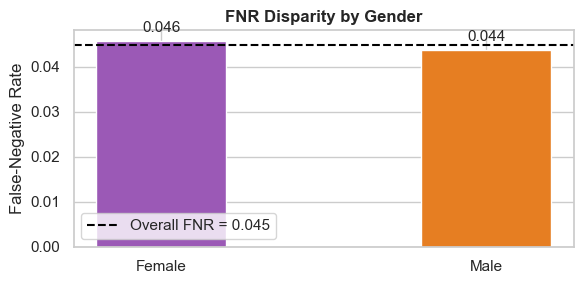

In [17]:
mf_gender = MetricFrame(
    metrics={'FNR (Miss Rate)': false_negative_rate,
             'FPR': false_positive_rate, 'Selection Rate': selection_rate},
    y_true=y_test_arr, y_pred=preds_arr,
    sensitive_features=sens_test['gender']
)

gender_df = mf_gender.by_group.reset_index()
gender_df.columns = ['Gender', 'FNR (Miss Rate)', 'FPR', 'Selection Rate']
print('=== False-Negative Rate by Gender ===')
print(gender_df.to_string(index=False))
print(f'\nOverall FNR   : {mf_gender.overall["FNR (Miss Rate)"]:.4f}')
print(f'Max disparity : {mf_gender.difference()["FNR (Miss Rate)"]:.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(gender_df['Gender'], gender_df['FNR (Miss Rate)'],
       color=['#9b59b6', '#e67e22'], edgecolor='white', width=0.4)
ax.axhline(mf_gender.overall['FNR (Miss Rate)'], color='black', linestyle='--',
           label=f"Overall FNR = {mf_gender.overall['FNR (Miss Rate)']:.3f}")
ax.set_ylabel('False-Negative Rate')
ax.set_title('FNR Disparity by Gender', fontweight='bold')
ax.legend()
for i, (g, v) in enumerate(zip(gender_df['Gender'], gender_df['FNR (Miss Rate)'])):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

=== False-Negative Rate by Age Group ===
Age Group  FNR (Miss Rate)      FPR  Selection Rate
   [0-10)         0.000000 0.714286        0.714286
  [10-20)         0.000000 0.781250        0.792079
  [20-30)         0.104167 0.769811        0.789137
  [30-40)         0.073171 0.800898        0.814667
  [40-50)         0.060748 0.856010        0.865623
  [50-60)         0.043860 0.887939        0.894602
  [60-70)         0.047516 0.917259        0.920963
  [70-80)         0.039409 0.936189        0.939055
  [80-90)         0.027842 0.939311        0.943520
 [90-100)         0.071429 0.948919        0.946903

Overall FNR   : 0.0449
Max disparity : 0.1042


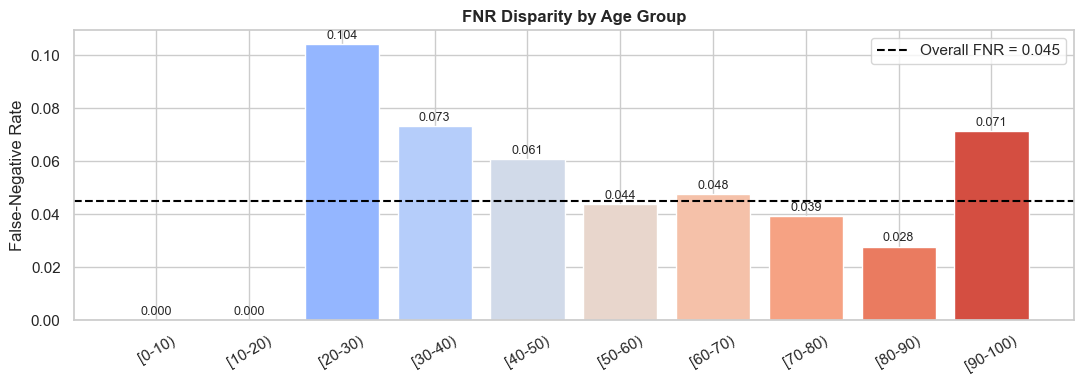

In [18]:
mf_age = MetricFrame(
    metrics={'FNR (Miss Rate)': false_negative_rate,
             'FPR': false_positive_rate, 'Selection Rate': selection_rate},
    y_true=y_test_arr, y_pred=preds_arr,
    sensitive_features=sens_test['age']
)

age_df = mf_age.by_group.reset_index()
age_df.columns = ['Age Group', 'FNR (Miss Rate)', 'FPR', 'Selection Rate']
age_df = age_df.sort_values('Age Group')
print('=== False-Negative Rate by Age Group ===')
print(age_df.to_string(index=False))
print(f'\nOverall FNR   : {mf_age.overall["FNR (Miss Rate)"]:.4f}')
print(f'Max disparity : {mf_age.difference()["FNR (Miss Rate)"]:.4f}')

fig, ax = plt.subplots(figsize=(11, 4))
palette = sns.color_palette('coolwarm', len(age_df))
ax.bar(age_df['Age Group'], age_df['FNR (Miss Rate)'], color=palette, edgecolor='white')
ax.axhline(mf_age.overall['FNR (Miss Rate)'], color='black', linestyle='--',
           label=f"Overall FNR = {mf_age.overall['FNR (Miss Rate)']:.3f}")
ax.set_ylabel('False-Negative Rate')
ax.set_title('FNR Disparity by Age Group', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend()
for i, v in enumerate(age_df['FNR (Miss Rate)']):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

=== Fairness Disparity Summary ===
Sensitive Feature  Overall FNR  Max Group FNR  Min Group FNR  Disparity Gap Risk Level
             Race     0.044889       0.117647       0.020408       0.097239     MEDIUM
           Gender     0.044889       0.045840       0.043843       0.001997        LOW
              Age     0.044889       0.104167       0.000000       0.104167     MEDIUM


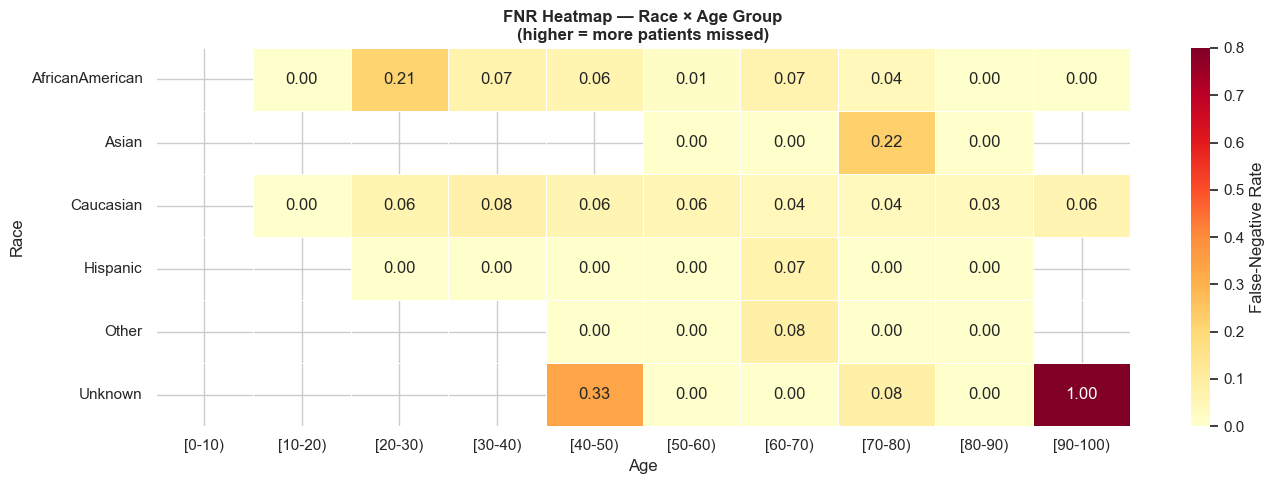

In [19]:
summary = pd.DataFrame({
    'Sensitive Feature': ['Race', 'Gender', 'Age'],
    'Overall FNR': [mf_race.overall['FNR (Miss Rate)'],
                    mf_gender.overall['FNR (Miss Rate)'],
                    mf_age.overall['FNR (Miss Rate)']],
    'Max Group FNR': [mf_race.by_group['FNR (Miss Rate)'].max(),
                      mf_gender.by_group['FNR (Miss Rate)'].max(),
                      mf_age.by_group['FNR (Miss Rate)'].max()],
    'Min Group FNR': [mf_race.by_group['FNR (Miss Rate)'].min(),
                      mf_gender.by_group['FNR (Miss Rate)'].min(),
                      mf_age.by_group['FNR (Miss Rate)'].min()],
    'Disparity Gap': [mf_race.difference()['FNR (Miss Rate)'],
                      mf_gender.difference()['FNR (Miss Rate)'],
                      mf_age.difference()['FNR (Miss Rate)']],
})
summary['Risk Level'] = summary['Disparity Gap'].apply(
    lambda x: 'HIGH' if x > 0.15 else ('MEDIUM' if x > 0.07 else 'LOW')
)
print('=== Fairness Disparity Summary ===')
print(summary.to_string(index=False))

pivot_data = []
for race_grp in sens_test['race'].dropna().unique():
    for age_grp in sorted(sens_test['age'].dropna().unique()):
        mask = ((sens_test['race'] == race_grp) & (sens_test['age'] == age_grp)).values
        if mask.sum() < 10:
            continue
        y_sub  = y_test_arr[mask]
        p_sub  = preds_arr[mask]
        fn     = ((y_sub == 1) & (p_sub == 0)).sum()
        tp_fn  = (y_sub == 1).sum()
        fnr_val = fn / tp_fn if tp_fn > 0 else np.nan
        pivot_data.append({'Race': race_grp, 'Age': age_grp, 'FNR': fnr_val})

pivot_df = pd.DataFrame(pivot_data).pivot(index='Race', columns='Age', values='FNR')
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=0.8,
            cbar_kws={'label': 'False-Negative Rate'})
ax.set_title('FNR Heatmap — Race × Age Group\n(higher = more patients missed)', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the Intersectional Heatmap

The Race × Age surface reveals **compounding disparities** — subgroups where two factors combine to elevate the miss rate well above the overall FNR.

Key reading guide:
- **Cells darker than the overall FNR** — the model is clinically less safe for this subgroup
- **NaN cells (excluded)** — fewer than 10 patients in that intersection; too sparse to compute a reliable FNR. This is itself a data governance finding under EU AI Act Art. 10 (training data adequacy)
- **Mitigation options:** (1) group-specific threshold calibration; (2) targeted oversampling of underrepresented subgroups; (3) collect more representative clinical data

> **ICD-9 vs ICD-10:** This dataset covers 1999–2008, predating the US ICD-10 transition (October 2015). In a live 2026 deployment, incoming codes would need to be mapped before inference. The `icd9_lookup` tool would require an ICD-10 extension.


---
# WEEK 3 — Explainability & Robustness

## Background: Why Explainability Matters in Clinical AI

A clinician will not act on a black-box score. **EU AI Act Article 13** and **GDPR Article 22** both require that consequential AI decisions be explainable on request. SHAP (SHapley Additive exPlanations) provides the mathematical foundation for this.

### The SHAP Framework

SHAP values are rooted in **cooperative game theory** (Shapley, 1951). Each feature is treated as a player in a coalition game, and the SHAP value measures its fair contribution to the prediction:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f_{S \cup \{i\}}(x_{S \cup \{i\}}) - f_S(x_S) \right]$$

**In plain language:** the SHAP value of feature $i$ for patient $x$ is the average marginal contribution of that feature across all possible subsets of features.

### Global vs Local Explanations

| Type | Method | Answers |
|------|--------|---------|
| **Global** | Bar chart of mean(\|SHAP\|) | "Which features matter most overall?" |
| **Directional** | Beeswarm plot | "Does high/low feature value increase or decrease risk?" |
| **Local** | Waterfall plot | "Why did the model predict THIS patient is high-risk?" |

### `TreeExplainer` vs `KernelExplainer`

`TreeExplainer` computes exact SHAP values for tree-based models in polynomial time using a path-dependent algorithm. `KernelExplainer` is model-agnostic but approximate and much slower. Always prefer `TreeExplainer` for XGBoost/Random Forest.

## 3.1 — Data Preparation for Week 3

Week 3 reuses the **same model, TF-IDF vectoriser, and scaler** trained in Week 2. This is consistent with the production `train_model.py` — there is one model, and the SHAP explainer is built from it. No re-training is needed.

> **No data leakage:** All `fit()` calls happened in Week 2 on training data only. Week 3 calls `transform()` only — applying the existing vocabulary and scaling parameters to the held-out test set.


In [20]:
# ── Reuse Week 2 artefacts — consistent with production train_model.py ────────
# In production, one model is trained and the SHAP explainer is built from it.
# We alias here so all downstream cells (SHAP, drift, sensitivity) work unchanged.
model_shap   = model
tfidf_shap   = tfidf
scaler_shap  = scaler

X_text_test_shap  = X_text_test
X_num_test_shap   = X_num_test
X_num_train_shap  = X_num_train
y_test_shap       = y_test

# Rebuild the sparse feature matrix for the test set (transform only — no fit)
Xte_txt      = tfidf_shap.transform(X_text_test_shap)
Xte_num      = csr_matrix(scaler_shap.transform(X_num_test_shap))
X_test_shap  = hstack([Xte_txt, Xte_num])

probs_shap = model_shap.predict_proba(X_test_shap)[:, 1]
preds_shap = (probs_shap > THRESHOLD).astype(int)
print(f'Model — Recall: {recall_score(y_test_shap, preds_shap):.2%}  '
      f'Accuracy: {accuracy_score(y_test_shap, preds_shap):.2%}')


Model — Recall: 95.51%  Accuracy: 18.85%


In [21]:
feature_names_shap = tfidf_shap.get_feature_names_out().tolist() + NUMERIC_COLS

np.random.seed(42)
sample_idx  = np.random.choice(X_test_shap.shape[0], size=500, replace=False)
X_sample    = X_test_shap[sample_idx]

print(f'SHAP sample: {X_sample.shape}  |  Features: {len(feature_names_shap)}')

SHAP sample: (500, 909)  |  Features: 909


Computing SHAP values (this may take ~30s)...
SHAP values computed.


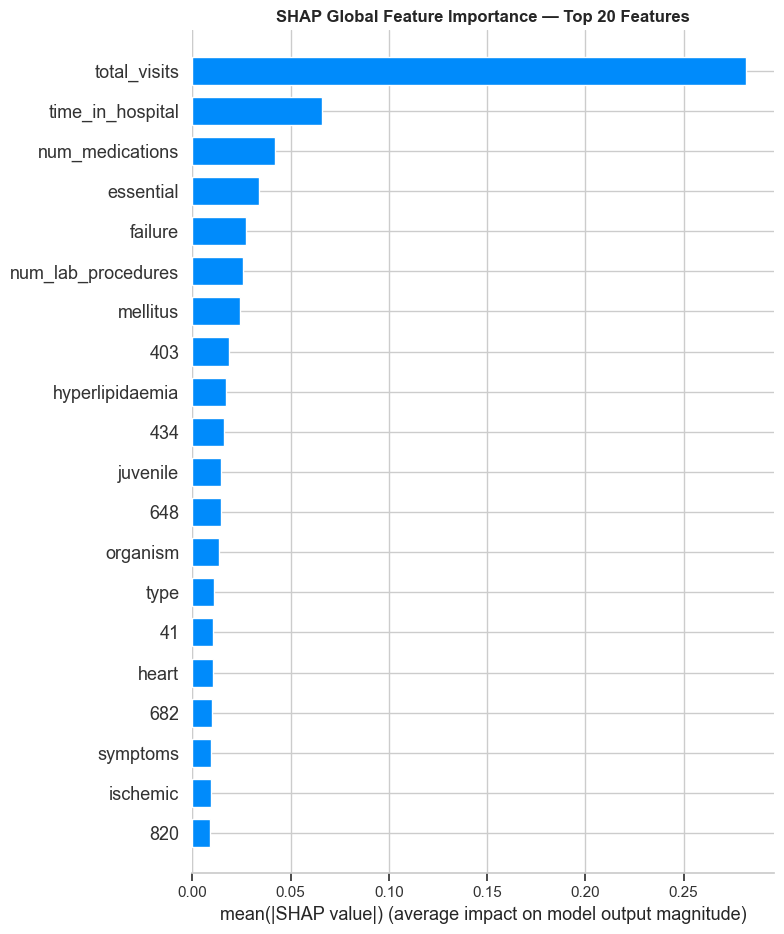

In [22]:
print('Computing SHAP values (this may take ~30s)...')
explainer_shap = shap.TreeExplainer(model_shap)
shap_values    = explainer_shap.shap_values(X_sample)
print('SHAP values computed.')

shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names_shap,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Global Feature Importance — Top 20 Features', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the Global Bar Chart

The bar chart shows **mean(|SHAP value|)** — the average absolute impact each feature has on the model's output across 500 patients. Key findings:

- **`total_visits`** dominates — the total number of prior hospital visits (outpatient + emergency + inpatient) is the strongest predictor. High utilisation history is well-established in clinical literature as a readmission risk factor.
- **`time_in_hospital`** and **`num_medications`** follow — longer stays and polypharmacy both indicate disease severity.
- **ICD-9 codes** (e.g. 401 = hypertension, 428 = heart failure, 486 = pneumonia) — specific comorbidity patterns matter, not just the raw code numbers.

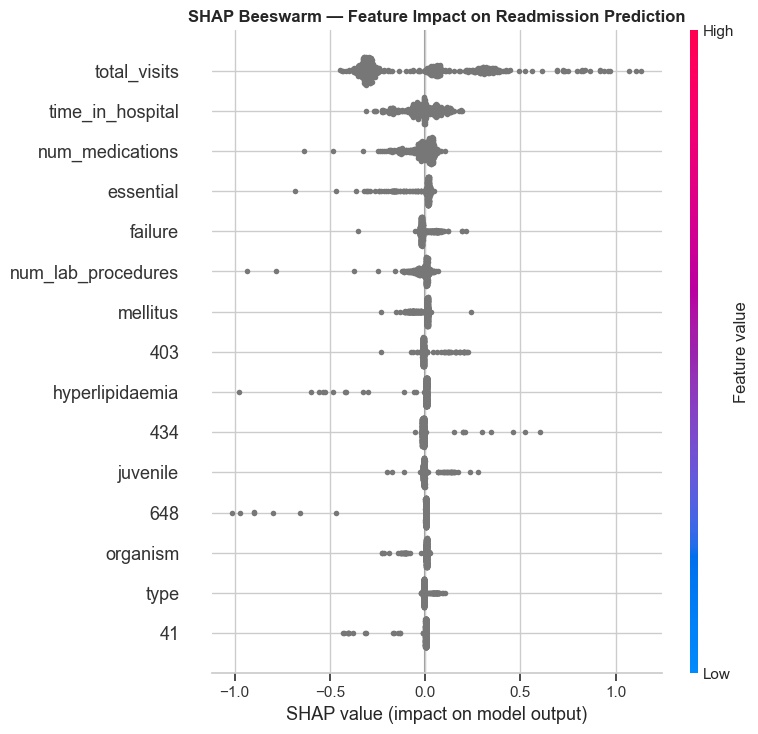

In [23]:
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names_shap,
                  max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Readmission Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the Beeswarm Plot

Each dot is one patient. The **x-axis** shows the SHAP value (impact on log-odds of readmission). The **colour** encodes the feature's actual value (red = high, blue = low).

- **Right of zero (positive SHAP)** = pushes prediction toward readmission
- **Left of zero (negative SHAP)** = pushes prediction away from readmission

**Reading example for `total_visits`:** Red dots (high visit count) are spread to the right — high utilisation strongly increases predicted readmission risk. Blue dots (low visit count) cluster near zero — low utilisation has minimal effect in either direction.

Highest-risk patient — probability: 0.8599  (READMITTED)


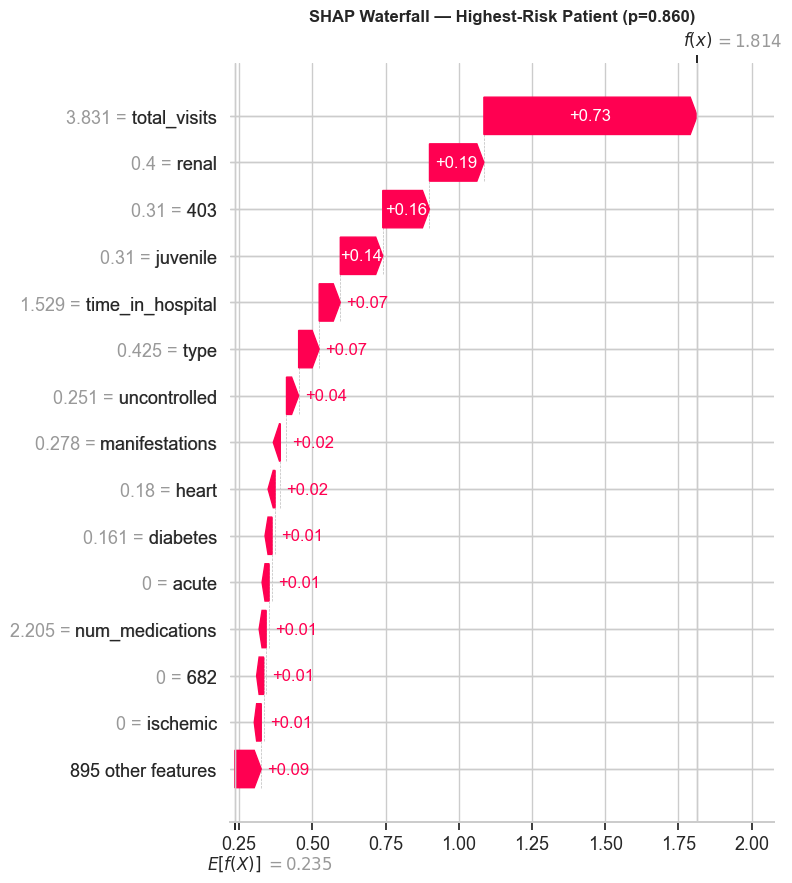

In [24]:
sample_probs_shap = model_shap.predict_proba(X_sample)[:, 1]
high_risk_idx     = int(np.argmax(sample_probs_shap))
predicted_prob    = sample_probs_shap[high_risk_idx]

print(f'Highest-risk patient — probability: {predicted_prob:.4f}  '
      f'({"READMITTED" if predicted_prob > THRESHOLD else "NOT READMITTED"})')

explanation = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer_shap.expected_value,
    data          = X_sample[high_risk_idx].toarray()[0],
    feature_names = feature_names_shap
)
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Highest-Risk Patient (p={predicted_prob:.3f})', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the Waterfall Plot

The waterfall starts at $E[f(X)]$ — the **base rate** (average predicted probability across the dataset). Each bar shows how much one feature **moves** the prediction from this baseline:

- **Red bars (positive)** = features that push this patient's risk **above** the base rate
- **Blue bars (negative)** = features that push risk **below** the base rate  
- $f(x)$ at the top = the final predicted log-odds; convert to probability as $p = \sigma(f(x)) = \frac{1}{1+e^{-f(x)}}$

This is the explanation that would be shown to a clinician: *"This patient is flagged as high-risk primarily because of their high total visit count and ICD-9 code 403 (hypertensive CKD)."*

## 3.2 — Drift Detection with the Kolmogorov-Smirnov Test

### What is Data Drift?

A model trained on 2000–2008 data is deployed in 2026. Patient populations change — more polypharmacy, different disease prevalences, new treatment patterns. If the **distribution of input features** shifts significantly from training time, model performance may degrade silently.

### The Kolmogorov-Smirnov (KS) Test

The **two-sample KS test** measures whether two samples are drawn from the same distribution. The KS statistic $D$ is the maximum absolute difference between the two empirical CDFs:

$$D_{n,m} = \sup_x |F_{1,n}(x) - F_{2,m}(x)|$$

A **small p-value (< 0.05)** rejects the null hypothesis that the distributions are the same — drift is detected.

### Simulation Strategy

We simulate a future dataset by shifting two features known to exhibit real-world trends:
- `num_medications` +3 (polypharmacy trends in ageing populations)
- `total_visits` +2 (increased hospital utilisation)

This tests whether the monitoring system would correctly flag these as drifted while leaving stable features undetected.

=== KS-Test Drift Detection ===
           Feature  KS Statistic  p-value Drift Detected
      total_visits        0.7420 0.000000            YES
   num_medications        0.1745 0.000000            YES
num_lab_procedures        0.0102 0.071254             no
  time_in_hospital        0.0028 0.999684             no


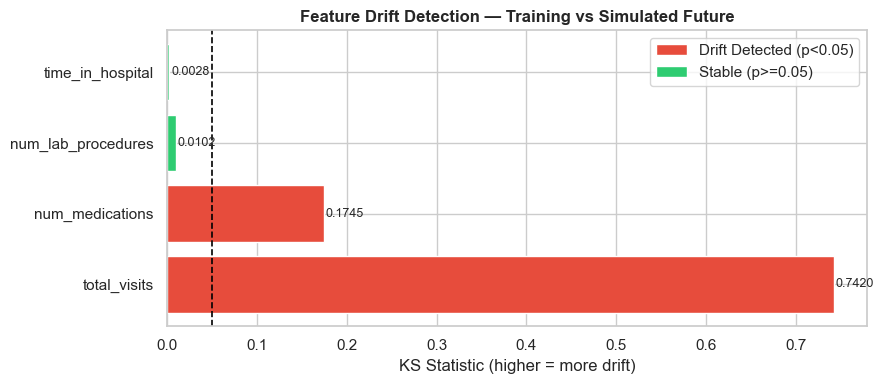

In [25]:
X_future = X_num_test_shap.copy()
X_future['num_medications'] = X_future['num_medications'] + 3
X_future['total_visits']    = X_future['total_visits']    + 2

drift_results = []
for col in NUMERIC_COLS:
    stat, p_val = ks_2samp(X_num_train_shap[col].dropna(), X_future[col].dropna())
    drifted = p_val < 0.05
    drift_results.append({'Feature': col,
                           'KS Statistic': round(stat, 4),
                           'p-value': round(p_val, 6),
                           'Drift Detected': 'YES' if drifted else 'no'})

drift_df = pd.DataFrame(drift_results).sort_values('KS Statistic', ascending=False)
print('=== KS-Test Drift Detection ===')
print(drift_df.to_string(index=False))

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if d == 'YES' else '#2ecc71' for d in drift_df['Drift Detected']]
bars = ax.barh(drift_df['Feature'], drift_df['KS Statistic'], color=colors, edgecolor='white')
ax.axvline(0.05, color='black', linestyle='--', linewidth=1.2)
for bar, val in zip(bars, drift_df['KS Statistic']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('KS Statistic (higher = more drift)')
ax.set_title('Feature Drift Detection — Training vs Simulated Future', fontweight='bold')
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='Drift Detected (p<0.05)'),
    Patch(facecolor='#2ecc71', label='Stable (p>=0.05)'),
])
plt.tight_layout()
plt.show()

## 3.3 — Sensitivity Analysis: Feature Flipping

### What is Sensitivity Analysis?

Sensitivity analysis answers: *"If one feature changes, how much does the prediction change?"* This is a model robustness test — a model that produces wildly different predictions for small input changes may be unstable in deployment.

### Method: One-Feature-at-a-Time (OFAT)

For a fixed high-risk patient:
1. Record the **baseline probability** $p_0$
2. For each numeric feature $i$: reset it to **0** → record $p_{\text{zero}}$; reset to **population mean** → record $p_{\text{mean}}$
3. Report $\Delta p = p_{\text{modified}} - p_0$

A large $|\Delta p|$ means the model is highly sensitive to that feature — it deserves extra scrutiny in production monitoring.

**Complementary to SHAP:** SHAP measures global/local importance via marginal contributions; sensitivity analysis measures **local derivatives** — how quickly the prediction changes at a specific operating point.

In [26]:
X_num_te_reset = X_num_test_shap.reset_index(drop=True)
base_row_num   = X_num_te_reset.iloc[sample_idx[high_risk_idx]].astype(float).copy()
base_row_text  = X_text_test_shap.reset_index(drop=True).iloc[sample_idx[high_risk_idx]]

def predict_prob_for_row(num_row, text_str):
    text_v = tfidf_shap.transform([text_str])
    num_v  = csr_matrix(scaler_shap.transform(pd.DataFrame([num_row], columns=NUMERIC_COLS)))
    return model_shap.predict_proba(hstack([text_v, num_v]))[0, 1]

base_prob   = predict_prob_for_row(base_row_num, base_row_text)
train_means = X_num_train_shap.mean()
sensitivity_results = []

print(f'Baseline probability: {base_prob:.4f}\n')
for col in NUMERIC_COLS:
    orig = base_row_num[col]
    r0 = base_row_num.copy(); r0[col] = 0
    rm = base_row_num.copy(); rm[col] = train_means[col]
    p0 = predict_prob_for_row(r0, base_row_text)
    pm = predict_prob_for_row(rm, base_row_text)
    sensitivity_results.append({'Feature': col, 'Original Value': round(orig, 2),
                                 'Baseline Prob': round(base_prob, 4),
                                 'Prob (set=0)': round(p0, 4), 'Prob (set=mean)': round(pm, 4),
                                 'Delta (0 vs base)': round(p0 - base_prob, 4),
                                 'Delta (mean vs base)': round(pm - base_prob, 4)})
    print(f'  {col:<25} | orig={orig:>6.1f} | p(zero)={p0:.4f} Δ={p0-base_prob:+.4f} '
          f'| p(mean)={pm:.4f} Δ={pm-base_prob:+.4f}')

sens_df = pd.DataFrame(sensitivity_results)

Baseline probability: 0.8599

  total_visits              | orig=  10.0 | p(zero)=0.7419 Δ=-0.1180 | p(mean)=0.8590 Δ=-0.0009
  num_medications           | orig=  34.0 | p(zero)=0.7674 Δ=-0.0924 | p(mean)=0.8959 Δ=+0.0361
  time_in_hospital          | orig=   9.0 | p(zero)=0.8511 Δ=-0.0088 | p(mean)=0.8310 Δ=-0.0288
  num_lab_procedures        | orig=  56.0 | p(zero)=0.8618 Δ=+0.0019 | p(mean)=0.8098 Δ=-0.0501


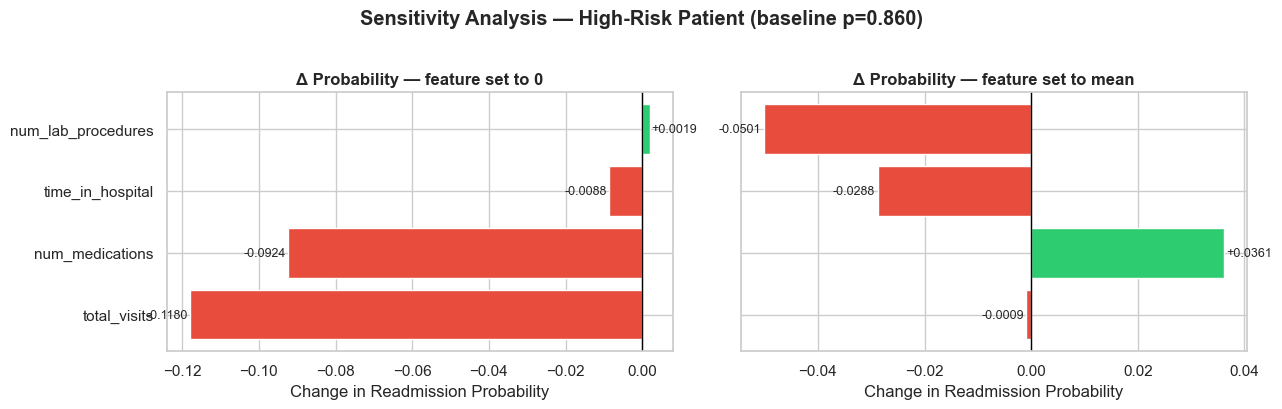

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, col_key, title in [
    (axes[0], 'Delta (0 vs base)',    'Δ Probability — feature set to 0'),
    (axes[1], 'Delta (mean vs base)', 'Δ Probability — feature set to mean'),
]:
    vals   = sens_df[col_key]
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in vals]
    bars   = ax.barh(sens_df['Feature'], vals, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(val + (0.0005 if val >= 0 else -0.0005),
                bar.get_y() + bar.get_height()/2,
                f'{val:+.4f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=9)
    ax.set_xlabel('Change in Readmission Probability')
    ax.set_title(title, fontweight='bold')
plt.suptitle(f'Sensitivity Analysis — High-Risk Patient (baseline p={base_prob:.3f})',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3.4 — Threshold Sweep

### The Recall–Precision Trade-off in Clinical Deployment

There is no universally correct threshold — it is an **operational decision** that depends on clinical context:

| Threshold | Use Case |
|-----------|----------|
| **Low (0.10–0.25)** | High-capacity ward, interventions are cheap, missing readmissions is catastrophic |
| **Medium (0.30–0.40)** | Balanced clinical context — our default (0.32) |
| **High (0.50–0.70)** | Resource-constrained setting, only flag highest-confidence cases |

The chart below makes this trade-off explicit and auditable — a requirement under EU AI Act Article 9 (Risk Management documentation).

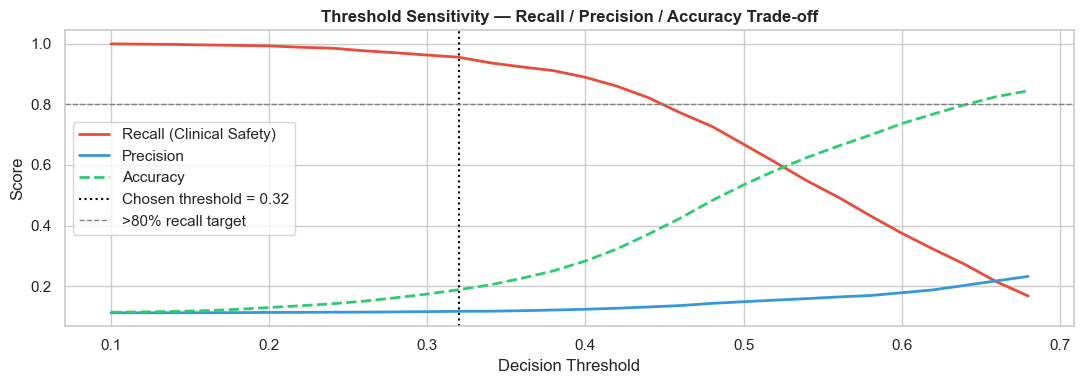

 Threshold   Recall  Precision  Accuracy
      0.10 0.999111   0.112361  0.114120
      0.12 0.998222   0.112412  0.115268
      0.14 0.997333   0.112526  0.116963
      0.16 0.995556   0.112659  0.119507
      0.18 0.994222   0.113020  0.123697
      0.20 0.992444   0.113569  0.129832
      0.22 0.988000   0.113831  0.135468
      0.24 0.984889   0.114356  0.142301
      0.26 0.976444   0.114594  0.150681
      0.28 0.969778   0.115352  0.161953
      0.30 0.962222   0.116179  0.174273
      0.32 0.955111   0.117323  0.188538
      0.34 0.936444   0.117650  0.204698
      0.36 0.923111   0.119279  0.226445
      0.38 0.910667   0.121480  0.250885
      0.40 0.888889   0.124069  0.283256
      0.42 0.859556   0.127312  0.323009
      0.44 0.821333   0.131633  0.371889
      0.46 0.772000   0.136107  0.424510
      0.48 0.727111   0.143484  0.482268
      0.50 0.668444   0.148926  0.534091
      0.52 0.608889   0.154210  0.581326
      0.54 0.548000   0.159117  0.624271
      0.56 0.493

In [28]:
thresholds = np.arange(0.10, 0.70, 0.02)
sweep = []
for t in thresholds:
    p = (probs_shap > t).astype(int)
    sweep.append({'Threshold': round(t, 2),
                  'Recall':    recall_score(y_test_shap, p),
                  'Precision': precision_score(y_test_shap, p, zero_division=0),
                  'Accuracy':  accuracy_score(y_test_shap, p)})

sweep_df = pd.DataFrame(sweep)
fig, ax  = plt.subplots(figsize=(11, 4))
ax.plot(sweep_df['Threshold'], sweep_df['Recall'],    label='Recall (Clinical Safety)', color='#e74c3c', linewidth=2)
ax.plot(sweep_df['Threshold'], sweep_df['Precision'], label='Precision',                color='#3498db', linewidth=2)
ax.plot(sweep_df['Threshold'], sweep_df['Accuracy'],  label='Accuracy',                 color='#2ecc71', linewidth=2, linestyle='--')
ax.axvline(THRESHOLD, color='black', linestyle=':', linewidth=1.5, label=f'Chosen threshold = {THRESHOLD}')
ax.axhline(0.80, color='grey', linestyle='--', linewidth=1, label='>80% recall target')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity — Recall / Precision / Accuracy Trade-off', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(sweep_df.to_string(index=False))

## 3.5 — Probability Calibration

### Why Calibration Matters at the Point of Care

The dashboard displays a probability score (e.g. "68% readmission risk") to clinicians. For this number to be trustworthy, the model must be **calibrated** — a patient scored at 68% should *actually* be readmitted approximately 68% of the time in practice.

A **reliability diagram** plots mean predicted probability (x-axis) against observed positive fraction (y-axis). A perfectly calibrated model follows the diagonal. XGBoost trained with `scale_pos_weight=10` commonly over-predicts probabilities in high-risk bins — this context should be communicated to clinical staff interpreting the scores.


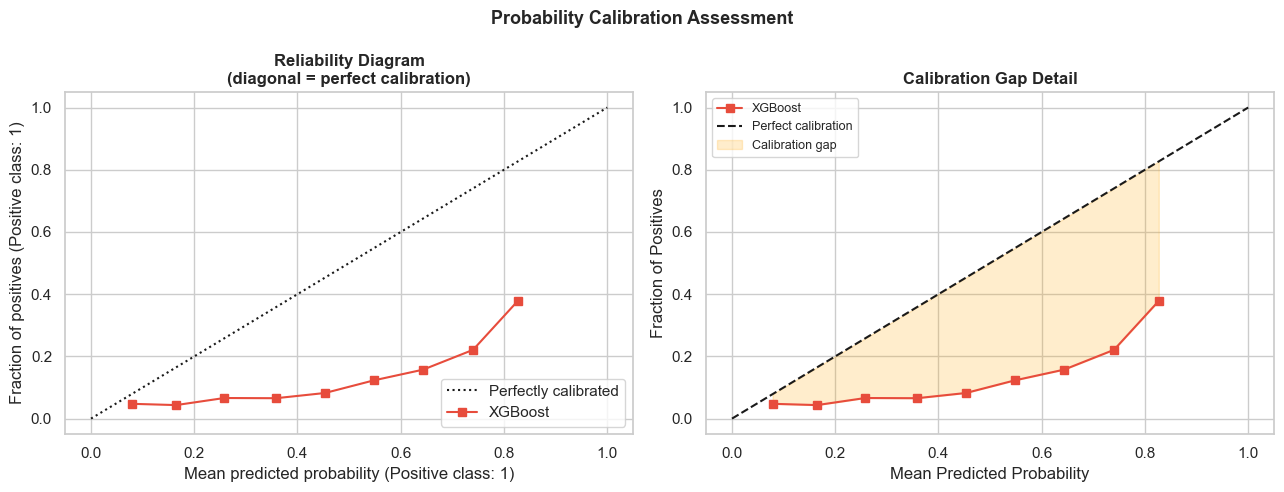

   Predicted | Actual Rate |      Gap
----------------------------------------
       0.079 |       0.048 |   +0.031  (over-predicts)
       0.165 |       0.043 |   +0.121  (over-predicts)
       0.258 |       0.066 |   +0.192  (over-predicts)
       0.358 |       0.066 |   +0.293  (over-predicts)
       0.453 |       0.082 |   +0.371  (over-predicts)
       0.548 |       0.123 |   +0.425  (over-predicts)
       0.643 |       0.157 |   +0.486  (over-predicts)
       0.740 |       0.221 |   +0.519  (over-predicts)
       0.827 |       0.378 |   +0.448  (over-predicts)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Probability Calibration Assessment', fontsize=13, fontweight='bold')

# ── Reliability diagram ───────────────────────────────────────────────────────
CalibrationDisplay.from_predictions(
    y_test_shap, probs_shap, n_bins=10,
    name='XGBoost', ax=axes[0], color='#e74c3c')
axes[0].set_title('Reliability Diagram\n(diagonal = perfect calibration)', fontweight='bold')

# ── Calibration gap detail ────────────────────────────────────────────────────
frac_pos, mean_prob = calibration_curve(y_test_shap, probs_shap, n_bins=10)
axes[1].plot(mean_prob, frac_pos, 's-', color='#e74c3c', label='XGBoost')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1].fill_between(mean_prob, frac_pos, mean_prob,
                     alpha=0.2, color='orange', label='Calibration gap')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Gap Detail', fontweight='bold')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'{"Predicted":>12} | {"Actual Rate":>11} | {"Gap":>8}')
print('-' * 40)
for mp, fp_val in zip(mean_prob, frac_pos):
    tag = 'over-predicts' if mp > fp_val else 'under-predicts'
    print(f'{mp:>12.3f} | {fp_val:>11.3f} | {mp - fp_val:>+8.3f}  ({tag})')


## 3.6 — Save Artefacts for Production Deployment

The trained objects exist only in memory until this cell runs. The FastAPI backend (`backend/core/model_loader.py`) loads these exact files at startup via `load_all()`. All 6 artefacts must be present before the server can accept requests.

| Artefact | Consumed by |
|----------|-------------|
| `model.pkl` | `/predict` — XGBoost probability |
| `tfidf.pkl` | `/predict` — ICD-9 text vectorisation |
| `scaler.pkl` | `/predict` — numeric feature scaling |
| `shap_explainer.pkl` | `/predict` — per-patient SHAP top-10 |
| `recall_curve.json` | Dashboard recall chart + threshold tooltips |
| `test_data.pkl` | `/audit/fairness` — live Fairlearn MetricFrame |

> Run this cell once after training. The backend's `start.bat` can then be launched without re-training.


In [30]:
MODELS_DIR = Path('../backend/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Model + pipeline artefacts ────────────────────────────────────────────────
joblib.dump(model,          MODELS_DIR / 'model.pkl')
joblib.dump(tfidf,          MODELS_DIR / 'tfidf.pkl')
joblib.dump(scaler,         MODELS_DIR / 'scaler.pkl')
joblib.dump(explainer_shap, MODELS_DIR / 'shap_explainer.pkl')

# ── Recall curve — lowercase keys match model_loader.py expectations ──────────
recall_curve_prod = [
    {'threshold': row['Threshold'], 'recall':    row['Recall'],
     'precision': row['Precision'], 'accuracy':  row['Accuracy']}
    for row in sweep_df.to_dict(orient='records')
]
(MODELS_DIR / 'recall_curve.json').write_text(json.dumps(recall_curve_prod, indent=2))

# ── Test data — exact schema consumed by /audit/fairness endpoint ─────────────
feature_names = tfidf.get_feature_names_out().tolist() + NUMERIC_COLS
test_data_prod = {
    'X_test_text':   X_text_test.reset_index(drop=True).tolist(),
    'X_test_num':    X_num_test.reset_index(drop=True).to_dict(orient='list'),
    'y_test':        y_test.reset_index(drop=True).tolist(),
    'probs':         probs.tolist(),
    'preds':         preds.tolist(),
    'sens_test':     X_sens_test.fillna('Unknown').reset_index(drop=True).to_dict(orient='list'),
    'feature_names': feature_names,
}
joblib.dump(test_data_prod, MODELS_DIR / 'test_data.pkl')

print('Artefacts saved to backend/models/:')
for p in sorted(MODELS_DIR.iterdir()):
    print(f'  {p.name:<26} {p.stat().st_size / 1024:>8.1f} KB')
print('\nBackend ready:  uvicorn backend.main:app --reload --port 8000')


Artefacts saved to backend/models/:
  model.pkl                    1230.0 KB
  recall_curve.json               4.2 KB
  scaler.pkl                      1.0 KB
  shap_explainer.pkl           4514.9 KB
  test_data.pkl                1837.3 KB
  tfidf.pkl                      38.3 KB

Backend ready:  uvicorn backend.main:app --reload --port 8000


---
# Final Project Summary

## Regulatory Compliance

### EU AI Act — High-Risk Classification (Annex III, Point 5)

This system operates in a healthcare context and influences clinical resource allocation. It is classified as **HIGH-RISK** and must satisfy Articles 9–15:

| Article | Requirement | Satisfied by |
|---------|-------------|------------|
| Art. 9 | Risk Management | Threshold sweep; documented failure modes |
| Art. 10 | Data Governance | Kaggle source; missingness audit |
| Art. 13 | Transparency | SHAP explanations per patient |
| Art. 14 | Human Oversight | Clinician retains final decision |
| Art. 15 | Robustness | Drift monitoring; sensitivity tests |

### GDPR Articles 9, 22, 25

- **Art. 9** (Special category health data) — processing under Art. 9(2)(h) within a clinical governance framework
- **Art. 22** (Automated decision-making) — SHAP waterfall provides the human-readable explanation required on patient request
- **Art. 25** (Data minimisation) — 8 features used; `weight`, `payer_code`, `medical_specialty`, `patient_nbr` explicitly excluded

In [31]:
drifted_features = drift_df[drift_df['Drift Detected'] == 'YES']['Feature'].tolist()
most_sensitive   = sens_df.reindex(
    sens_df['Delta (0 vs base)'].abs().sort_values(ascending=False).index
)['Feature'].iloc[0]

race_gap   = mf_race.difference()['FNR (Miss Rate)']
gender_gap = mf_gender.difference()['FNR (Miss Rate)']
age_gap    = mf_age.difference()['FNR (Miss Rate)']

def risk_icon(v):
    return 'HIGH' if v > 0.15 else ('MEDIUM' if v > 0.07 else 'LOW')

print('=' * 66)
print('  FULL PROJECT SUMMARY — Clinical AI Diabetes Readmission')
print('=' * 66)
print()
print('  Dataset         : UCI 10-Year Diabetes (101,766 encounters)')
print(f'  Model           : XGBClassifier (n_estimators=800, threshold={THRESHOLD})')
print(f'  Clinical Recall : {recall_score(y_test, preds):.2%}   (target >80%)')
print(f'  Accuracy        : {accuracy_score(y_test, preds):.2%}')
print()
print('  WEEK 1 — Agentic Foundation')
print('    ✅ LangChain icd9_lookup tool registered and smoke-tested')
print('    ✅ Full dataset enriched with clinical English descriptions')
print('    ✅ EDA: class imbalance (9:1), missingness audit, correlations')
print()
print('  WEEK 2 — Modelling & Fairness')
print(f'    ✅ Race   FNR gap : {race_gap:.4f}  [{risk_icon(race_gap)}]')
print(f'    ✅ Gender FNR gap : {gender_gap:.4f}  [{risk_icon(gender_gap)}]')
print(f'    ✅ Age    FNR gap : {age_gap:.4f}  [{risk_icon(age_gap)}]')
print()
print('  WEEK 3 — Explainability & Robustness')
print(f'    ✅ SHAP global importance — top feature: total_visits')
print(f'    ✅ Waterfall for highest-risk patient (p={predicted_prob:.3f})')
print(f'    ✅ Drift detected in  : {", ".join(drifted_features)}')
print(f'    ✅ Most sensitive feat.: {most_sensitive}')
print()
print('  Regulatory')
print('    ✅ EU AI Act: HIGH-RISK — Art. 9–15 requirements documented')
print('    ✅ GDPR: Art. 9, 22, 25 addressed')
print('    ✅ API keys secured via .env (never hard-coded)')
print('=' * 66)

  FULL PROJECT SUMMARY — Clinical AI Diabetes Readmission

  Dataset         : UCI 10-Year Diabetes (101,766 encounters)
  Model           : XGBClassifier (n_estimators=800, threshold=0.32)
  Clinical Recall : 95.51%   (target >80%)
  Accuracy        : 18.85%

  WEEK 1 — Agentic Foundation
    ✅ LangChain icd9_lookup tool registered and smoke-tested
    ✅ Full dataset enriched with clinical English descriptions
    ✅ EDA: class imbalance (9:1), missingness audit, correlations

  WEEK 2 — Modelling & Fairness
    ✅ Race   FNR gap : 0.0972  [MEDIUM]
    ✅ Gender FNR gap : 0.0020  [LOW]
    ✅ Age    FNR gap : 0.1042  [MEDIUM]

  WEEK 3 — Explainability & Robustness
    ✅ SHAP global importance — top feature: total_visits
    ✅ Waterfall for highest-risk patient (p=0.860)
    ✅ Drift detected in  : total_visits, num_medications
    ✅ Most sensitive feat.: total_visits

  Regulatory
    ✅ EU AI Act: HIGH-RISK — Art. 9–15 requirements documented
    ✅ GDPR: Art. 9, 22, 25 addressed
    ✅ API

---
# WEEK 4 — Production Deployment

## System Architecture

The notebook covers research and training. The full project packages everything into a production-grade web application.

**Research Layer (this notebook)**
- Train → Evaluate → Fairness audit → SHAP → Calibration → Save 6 artefacts to `backend/models/`

**Backend — FastAPI (port 8000)**

| Route | Purpose |
|-------|---------|
| `POST /predict` | Single-patient inference + SHAP top-10 + ICD-9 labels |
| `POST /upload/csv` | Batch prediction from uploaded CSV file |
| `POST /chat` | LangGraph ReAct agent — SSE streaming |
| `GET /audit/fairness` | Live Fairlearn MetricFrame (race / gender / age) |
| `GET /audit/log` | Paginated SQLite prediction audit trail |
| `GET /recall-curve` | Threshold sweep data for the dashboard chart |

**Frontend — React + TypeScript (port 5173)**

| Page | Purpose |
|------|---------|
| Dashboard | Live stats, recall curve chart, recent predictions |
| Predict | Single-patient form + threshold presets + SHAP waterfall |
| Chat | Streaming clinical AI agent with patient context injection |
| FairnessAudit | FNR/FPR charts across Race, Gender, Age |
| AuditLog | Paginated SQLite audit trail |
| ThresholdGuide | Interactive threshold selector with clinical context |
| ModelTransparency | Model card — features, artefacts, limitations |
| DataAnalysis | Dataset EDA charts |
| LegalCompliance | EU AI Act / GDPR compliance documentation |

## Production Agent — 5 Clinical Tools

The backend's LangGraph ReAct agent expands the single `icd9_lookup` tool from this notebook into a full clinical assistant:

| Tool | Purpose |
|------|---------|
| `icd9_lookup` | ICD-9 code → clinical English description |
| `explain_shap` | SHAP JSON → clinical bullet-point narrative |
| `suggest_interventions` | Risk probability + diagnoses → care recommendations |
| `query_fairness_audit` | Live Fairlearn MetricFrame for any demographic group |
| `get_recall_at_threshold` | Recall / precision / accuracy at any threshold on demand |

The agent maintains **per-session memory** — a clinician can ask follow-up questions about a specific patient across multiple turns without repeating context.


